<a href="https://colab.research.google.com/github/tanbirali/tumour_class_prediction/blob/main/tumour_class_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Classification with Hybrid ResNet-ViT Model

This notebook demonstrates a complete workflow for brain tumor classification using a hybrid ResNet-Vision Transformer (ViT) model. It includes data loading, preprocessing, model definition with regularization (dropout), training with early stopping, and comprehensive evaluation.

## 1. Setup and Data Preparation

In [1]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import cycle
import random
from google.colab import drive

drive.mount('/content/drive/')

# Ensure the dataset is extracted if it's not already present
extract_path = '/content/dataset'
zip_path = '/content/drive/MyDrive/BrainTumor_multiclass.zip'

if not os.path.exists(extract_path):
    print(f"Extracting {zip_path} to {extract_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print(f"Directory {extract_path} already exists. Skipping extraction.")

# Define transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Set extracted base directory
extracted_base_dir = '/content/dataset'

# Use os.listdir to get the content of the extracted directory
content_of_extracted_dir = os.listdir(extracted_base_dir)

# Check if content_of_extracted_dir is not empty and get dataset_folder_name
if not content_of_extracted_dir:
    raise FileNotFoundError(f"The directory '{extracted_base_dir}' is empty after extraction. Zip extraction might have failed or extracted an empty directory.")

# Assuming the dataset folder is the first item in the extracted directory
dataset_folder_name = content_of_extracted_dir[0]

# Construct train_dir and test_dir using os.path.join
train_dir = os.path.join(extracted_base_dir, dataset_folder_name, 'Training')
test_dir = os.path.join(extracted_base_dir, dataset_folder_name, 'Testing')

# Create train_dataset and test_dataset using datasets.ImageFolder
train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms)

# Define split ratio (e.g., 80% train, 20% validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Split the training dataset
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Original training dataset size: {len(train_dataset)}")
print(f"New training subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")
print(f"Number of batches in new train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")
print(f"Classes found: {train_dataset.classes}")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Extracting /content/drive/MyDrive/BrainTumor_multiclass.zip to /content/dataset...
Extraction complete.
Original training dataset size: 2870
New training subset size: 2296
Validation subset size: 574
Number of batches in new train_loader: 72
Number of batches in val_loader: 18
Number of batches in test_loader: 13
Classes found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## 2. Model Definition: Hybrid ResNet-ViT with Dropout

In [2]:
class HybridTumorModel(nn.Module):
    def __init__(self, num_classes=4, embed_dim=768, dropout_rate=0.5):
        super().__init__()

        # 1. ResNet Backbone (Feature Extraction)
        resnet = models.resnet50(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) # Output: [B, 2048, 7, 7]

        # 2. Feature Map to Patch Embedding (The Bridge)
        self.bridge = nn.Conv2d(2048, embed_dim, kernel_size=1)

        # 3. Vision Transformer Encoder (Attention Learning)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 50, embed_dim)) # 49 patches + 1 cls

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=8, batch_first=True)
        self.vit_encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)

        # Add Dropout layer for regularization
        self.dropout = nn.Dropout(dropout_rate)

        # 4. FC Layer -> Softmax (Classifier)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Feature Extraction
        x = self.backbone(x)           # [Batch, 2048, 7, 7]

        # Patch Embedding
        x = self.bridge(x)             # [Batch, 768, 7, 7]
        x = x.flatten(2).transpose(1, 2) # [Batch, 49, 768]

        # Prepend CLS token and add Position
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed

        # Attention Feature Learning
        x = self.vit_encoder(x)

        # Apply dropout before the classifier
        x = self.dropout(x[:, 0])

        # Classification (Softmax is handled by CrossEntropyLoss during training)
        return self.classifier(x)

num_classes = len(train_dataset.classes)
model = HybridTumorModel(num_classes=num_classes).to('cpu')

print("HybridTumorModel with dropout layer defined and instantiated.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 137MB/s]


HybridTumorModel with dropout layer defined and instantiated.


## 3. Training with Early Stopping

In [3]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=10, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

print("EarlyStopping class defined.")

EarlyStopping class defined.


In [4]:
# Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-instantiate model to ensure it's on the correct device and re-initialize weights
model = HybridTumorModel(num_classes=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Instantiate EarlyStopping callback
early_stopping = EarlyStopping(patience=10, verbose=True, path='best_model.pt')

# Training loop with validation and early stopping
epochs = 75 # Max epochs, actual epochs might be less due to early stopping

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    # Validation Phase
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculations for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = running_val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping check
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered!")
        break

# Load the best model weights if early stopping occurred
if early_stopping.early_stop:
    model.load_state_dict(torch.load('best_model.pt'))
    print("Loaded best model due to early stopping.")
else:
    print("Training finished without early stopping criteria being met.")

Epoch 1/75 - Train Loss: 0.6485, Val Loss: 0.2929
Validation loss decreased (inf --> 0.292933).  Saving model ...
Epoch 2/75 - Train Loss: 0.1828, Val Loss: 0.1771
Validation loss decreased (0.292933 --> 0.177118).  Saving model ...
Epoch 3/75 - Train Loss: 0.1243, Val Loss: 0.1392
Validation loss decreased (0.177118 --> 0.139153).  Saving model ...
Epoch 4/75 - Train Loss: 0.0607, Val Loss: 0.1861
EarlyStopping counter: 1 of 10
Epoch 5/75 - Train Loss: 0.0744, Val Loss: 0.2388
EarlyStopping counter: 2 of 10
Epoch 6/75 - Train Loss: 0.0611, Val Loss: 0.1901
EarlyStopping counter: 3 of 10
Epoch 7/75 - Train Loss: 0.0986, Val Loss: 0.1447
EarlyStopping counter: 4 of 10
Epoch 8/75 - Train Loss: 0.0362, Val Loss: 0.2092
EarlyStopping counter: 5 of 10
Epoch 9/75 - Train Loss: 0.0366, Val Loss: 0.2265
EarlyStopping counter: 6 of 10
Epoch 10/75 - Train Loss: 0.0418, Val Loss: 0.1346
Validation loss decreased (0.139153 --> 0.134631).  Saving model ...
Epoch 11/75 - Train Loss: 0.0443, Val Loss

## 4. Model Evaluation


Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.20      0.33       100
meningioma_tumor       0.61      1.00      0.76       115
        no_tumor       0.83      0.99      0.90       105
 pituitary_tumor       1.00      0.84      0.91        74

        accuracy                           0.76       394
       macro avg       0.86      0.76      0.73       394
    weighted avg       0.84      0.76      0.72       394



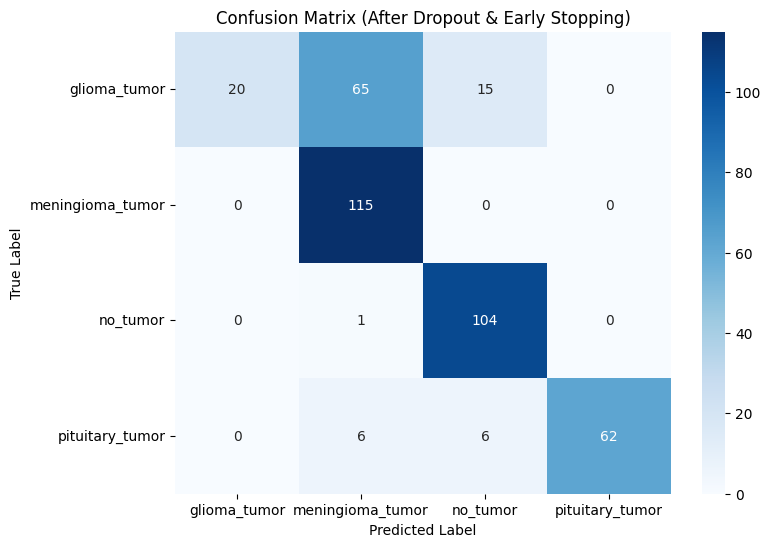

In [5]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (After Dropout & Early Stopping)')
plt.show()

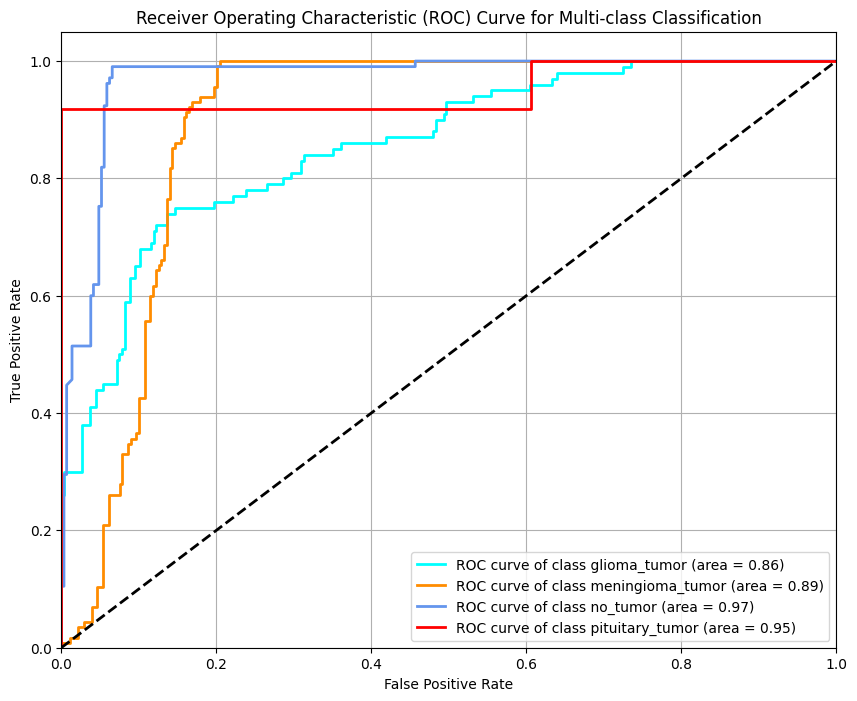

In [6]:
model.eval()
all_probs = []
all_labels_roc = [] # Use a different variable name to avoid confusion with previous all_labels

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels_roc.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

# Binarize the labels for ROC curve calculation
n_classes = len(train_dataset.classes)
binary_labels = np.zeros((len(all_labels_roc), n_classes))
for i in range(len(all_labels_roc)):
    binary_labels[i, all_labels_roc[i]] = 1

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binary_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(train_dataset.classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 5. Live Demo: Predict on a Random Image

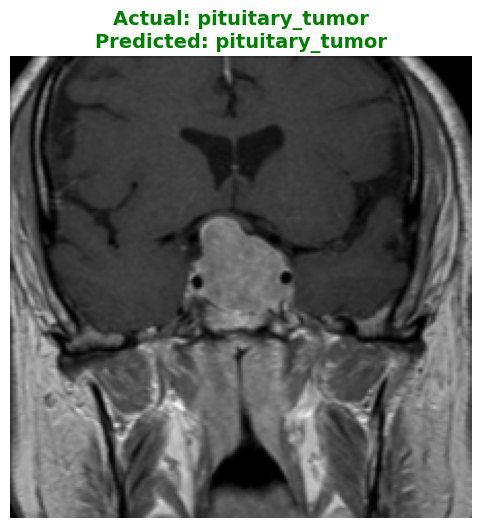

In [8]:
def predict_random_image(model, dataset, device):
    model.eval()

    # Pick a random index from the test dataset
    random_idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[random_idx]

    # Prepare image for model (Add batch dimension and move to device)
    input_tensor = image.unsqueeze(0).to(device)

    # Get Prediction
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)

    # Convert tensor back to image for display
    display_img = image.permute(1, 2, 0).cpu().numpy()

    # Un-normalize the image for better viewing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    display_img = std * display_img + mean
    display_img = np.clip(display_img, 0, 1)

    # Show Result
    plt.figure(figsize=(6, 6))
    plt.imshow(display_img)

    actual_name = dataset.classes[label]
    predicted_name = dataset.classes[predicted.item()]

    color = 'green' if actual_name == predicted_name else 'red'

    plt.title(f"Actual: {actual_name}\nPredicted: {predicted_name}",
              color=color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# Run the live demo
predict_random_image(model, test_dataset, device)